# 🚀 Practice Day 16

**📅 Date:** 2026-09-27  
**📁 Category:** Phase 1 · NumPy 기초 (Round 2/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Practice vectorized NumPy array operations — no explicit Python loops (순수 배열 연산으로, 반복문 없이 계산)
- Combine multiple arrays into a derived business metric, with a conditional multiplier (여러 배열을 조합해 조건부 배율까지 포함한 파생 지표 계산)
- Use boolean masking to filter and summarize data (불리언 마스킹으로 필터링·요약)
- Same skills as Day 2, new dataset (Day 2와 같은 스킬, 새로운 데이터로 연습)

---
# 📂 Dataset

**Dataset Name:** Taxi Fare Data (택시 요금 데이터)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** 280 taxi trips with distance, duration, taxi type (Standard/Deluxe, each with its own base fare and per-km rate, in USD), and whether the trip happened at night (20% late-night surcharge applies). The numeric columns are also kept as plain NumPy arrays so you can practice raw array operations directly, not only through pandas.
(택시 트립 280건 — 거리, 소요시간, 택시 유형(Standard/Deluxe, 각각 기본요금·km당 요금 다름, USD), 심야 여부(심야는 20% 할증) 포함. 수치형 컬럼들은 순수 NumPy 배열로도 그대로 남아있어서 pandas 없이 배열 연산만으로 연습 가능합니다.)

## Dataset Preview

In [1]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

n_trips = 280

distance_km = np.round(np.random.uniform(0.5, 15.0, n_trips), 1)

# duration roughly follows distance (~2.8 min/km) plus traffic noise
duration_min = np.round(distance_km * 2.8 + np.random.normal(5, 3, n_trips)).astype(int)
duration_min = np.clip(duration_min, 3, None)

taxi_type = np.random.choice(['Standard', 'Deluxe'], size=n_trips, p=[0.85, 0.15])
# fares in USD
base_fare = np.where(taxi_type == 'Deluxe', 7.00, 4.80)
per_km_rate = np.where(taxi_type == 'Deluxe', 1.60, 1.00)

is_late_night = np.random.choice([True, False], size=n_trips, p=[0.25, 0.75])

# distance_km / duration_min / base_fare / per_km_rate / is_late_night stay available
# as plain NumPy arrays below (not just inside df) - use them directly in the Analysis section.
df = pd.DataFrame({
    'trip_id': [f'TRIP-{i+1:05d}' for i in range(n_trips)],
    'distance_km': distance_km,
    'duration_min': duration_min,
    'taxi_type': taxi_type,
    'is_late_night': is_late_night,
    'base_fare': base_fare,
    'per_km_rate': per_km_rate,
})

df.head()

,trip_id,distance_km,duration_min,taxi_type,is_late_night,base_fare,per_km_rate
0,TRIP-00001,5.9,21,Standard,False,4.8,1.0
1,TRIP-00002,14.3,47,Standard,False,4.8,1.0
2,TRIP-00003,11.1,34,Standard,True,4.8,1.0
3,TRIP-00004,9.2,30,Standard,False,4.8,1.0
4,TRIP-00005,2.8,11,Standard,True,4.8,1.0


## Dataset Information

In [2]:
# Dataset Information
print(df.shape)
df.info()
df.describe()

(280, 7)
<class 'pandas.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   trip_id        280 non-null    str    
 1   distance_km    280 non-null    float64
 2   duration_min   280 non-null    int64  
 3   taxi_type      280 non-null    str    
 4   is_late_night  280 non-null    bool   
 5   base_fare      280 non-null    float64
 6   per_km_rate    280 non-null    float64
dtypes: bool(1), float64(3), int64(1), str(2)
memory usage: 13.5 KB


,distance_km,duration_min,base_fare,per_km_rate
count,280.000000,280.000000,280.000000,280.000000
mean,7.790000,26.857143,5.106429,1.083571
std,4.275416,12.192054,0.763102,0.208119
min,0.600000,3.000000,4.800000,1.000000
25%,4.000000,16.000000,4.800000,1.000000
50%,8.000000,27.000000,4.800000,1.000000
75%,11.550000,38.000000,4.800000,1.000000
max,14.900000,51.000000,7.000000,1.600000


---
# ❓ Business Questions

1. What is the total fare for each trip — base fare + (distance × per-km rate), with a 20% late-night surcharge applied where relevant? (각 트립의 총 요금은 — 기본요금 + 거리×km당요금에, 해당되면 심야 20% 할증까지 적용?)
2. How many trips were late-night, and what percentage of all trips is that? (심야 트립은 몇 건이며 전체의 몇 %인가?)
3. What are the mean, median, and standard deviation of total fare? (총 요금의 평균/중앙값/표준편차는?)
4. What does the distribution of total fare look like? (총 요금의 분포는 어떤 모습인가?)
5. How does average total fare differ between Standard and Deluxe taxis? (택시 유형별 평균 총 요금 차이는?)

---
# 🛠 Skills Used
- [x] Python
- [x] NumPy — `np.where`, `np.mean`, `np.median`, `np.std`
  (조건부 배율, 평균, 중앙값, 표준편차)
- [x] Pandas — column math, boolean mask, `groupby().mean()`
  (컬럼 연산, 불리언 마스크, 그룹별 평균)
- [ ] SQL
- [x] Matplotlib — `ax.hist`, `ax.bar`
  (히스토그램, 막대 차트)
- [ ] Other: 

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0
  (결측 없음)
- [x] Duplicate Rows — 0
  (중복 행 없음)
- [x] Wrong Data Types — `is_late_night` is bool, fares are float, `duration_min` is int; no fix needed
  (is_late_night는 bool, 요금은 실수, duration_min은 정수. 수정 불필요)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [3]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
trip_id          0
distance_km      0
duration_min     0
taxi_type        0
is_late_night    0
base_fare        0
per_km_rate      0
dtype: int64

Duplicate rows: 0

Dtypes
trip_id              str
distance_km      float64
duration_min       int64
taxi_type            str
is_late_night       bool
base_fare        float64
per_km_rate      float64
dtype: object

Column names
['trip_id', 'distance_km', 'duration_min', 'taxi_type', 'is_late_night', 'base_fare', 'per_km_rate']

Text columns — unique counts
trip_id      280
taxi_type      2
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** What is the total fare for each trip — base fare + (distance × per-km rate), with a 20% late-night surcharge applied where relevant? (각 트립의 총 요금은 — 기본요금 + 거리×km당요금에, 해당되면 심야 20% 할증까지 적용?)

**Result:** A `total_fare` column was added for all **280** trips. Total fares range from about **$5.40** to **$35.28**.
(280개 트립 모두에 total_fare 컬럼을 추가. 총 요금은 약 $5.40~$35.28)

**Insight:** The fare depends on the base fare, the distance, the per-km rate, and the late-night surcharge, so it varies a lot from trip to trip.
(요금은 기본요금, 거리, km당 요금, 심야 할증에 따라 달라서 트립마다 크게 다름)

In [ ]:
# Question 1: subtotal = base_fare + distance_km * per_km_rate
# total_fare = subtotal * 1.2 if is_late_night else subtotal (per trip)
# Tip: use the raw NumPy arrays, and np.where() for the conditional multiplier

df['total_fare'] = df['base_fare'] + df['distance_km'] * df['per_km_rate']
df['total_fare'] = np.where(df['is_late_night'], df['total_fare'] * 1.2, df['total_fare'])

df

,trip_id,distance_km,duration_min,taxi_type,is_late_night,base_fare,per_km_rate,total_fare
0,TRIP-00001,5.9,21,Standard,False,4.8,1.0,10.70
1,TRIP-00002,14.3,47,Standard,False,4.8,1.0,19.10
2,TRIP-00003,11.1,34,Standard,True,4.8,1.0,19.08
3,TRIP-00004,9.2,30,Standard,False,4.8,1.0,14.00
4,TRIP-00005,2.8,11,Standard,True,4.8,1.0,9.12
...,...,...,...,...,...,...,...,...
275,TRIP-00276,7.8,29,Standard,False,4.8,1.0,12.60
276,TRIP-00277,12.1,39,Standard,False,4.8,1.0,16.90
277,TRIP-00278,9.9,37,Standard,False,4.8,1.0,14.70
278,TRIP-00279,10.7,35,Standard,False,4.8,1.0,15.50


## Question 2

**Question:** How many trips were late-night, and what percentage of all trips is that? (심야 트립은 몇 건이며 전체의 몇 %인가?)

**Result:** **70** trips were late-night, which is **25.00%** of all 280 trips.
(심야 트립은 70건으로 전체 280건의 25.00%)

**Insight:** One in four trips is late-night, so the 20% surcharge applies to a quarter of all trips.
(4건 중 1건이 심야라, 20% 할증이 적용되는 트립이 전체의 4분의 1)

In [ ]:
# Question 2: Count trips where is_late_night is True, and their share of all trips

late_night_trips = df[df['is_late_night']].shape[0]
total_trips = df.shape[0]
late_night_percentage = (late_night_trips / total_trips) * 100

print(f"Late-night trips: {late_night_trips}")
print(f"Late-night percentage: {late_night_percentage:.2f}%")


Late-night trips: 70
Late-night percentage: 25.00%


## Question 3

**Question:** What are the mean, median, and standard deviation of total fare? (총 요금의 평균/중앙값/표준편차는?)

**Result:** Mean total fare is **$14.15**, median is **$14.61**, and the standard deviation is **$5.40**.
(총 요금 평균 $14.15, 중앙값 $14.61, 표준편차 $5.40)

**Insight:** The mean and the median are close, so a typical fare is about **$14 to $15**. The standard deviation of **$5.40** shows that fares spread widely around it.
(평균과 중앙값이 비슷해 일반적인 요금은 약 $14~$15. 표준편차 $5.40은 그 주변에서 넓게 퍼져 있다는 뜻)

In [10]:
# Question 3: mean, median, and standard deviation of total_fare (from Question 1)
# Tip: np.mean(), np.median(), np.std()

total_fare_mean = np.mean(df['total_fare'])
total_fare_median = np.median(df['total_fare'])
total_fare_std = np.std(df['total_fare'])

print(f"Mean total fare: ${total_fare_mean:.2f}")
print(f"Median total fare: ${total_fare_median:.2f}")
print(f"Standard deviation of total fare: ${total_fare_std:.2f}")

Mean total fare: $14.15
Median total fare: $14.61
Standard deviation of total fare: $5.40


---
# 📈 Visualization

**Chart 1:** Distribution of total fare (histogram) — 총 요금 분포

*Interpretation:* Most trips fall between about **$5** and **$20**, and the right side above $20 is sparse, with a thin tail up to about **$35**. There is one tallest bar (about $16 to $17) and about four other tall bars, so the shape is bumpy rather than a single smooth peak.
(대부분 트립은 약 $5~$20 사이. $20 넘는 오른쪽은 거의 없고 약 $35까지 얇은 꼬리. 가장 높은 막대 1개(약 $16~$17)와 높은 막대 약 4개가 있어 하나의 매끄러운 봉우리가 아니라 울통불통한 모양)

---

**Chart 2:** Average total fare by taxi type (bar chart) — 택시 유형별 평균 총 요금

*Interpretation:* Deluxe averages about **$19.5** and Standard about **$13.3**, so Deluxe is about **$6** higher. Deluxe has both a higher base fare ($7.00 vs $4.80) and a higher per-km rate ($1.60 vs $1.00).
(Deluxe 평균 약 $19.5, Standard 약 $13.3으로 Deluxe가 약 $6 더 높음. Deluxe는 기본요금($7.00 vs $4.80)과 km당 요금($1.60 vs $1.00)이 모두 더 높음)

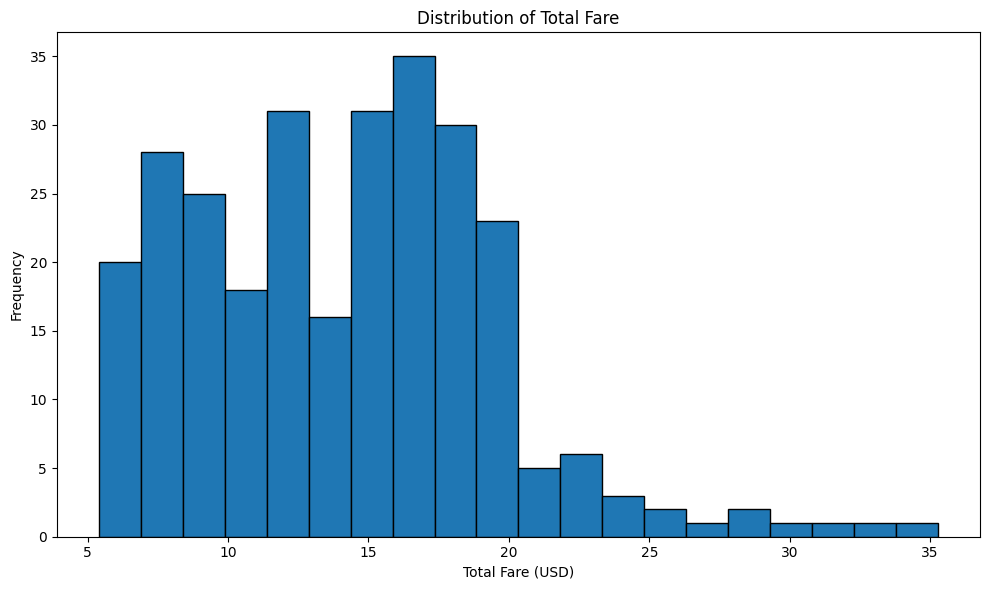

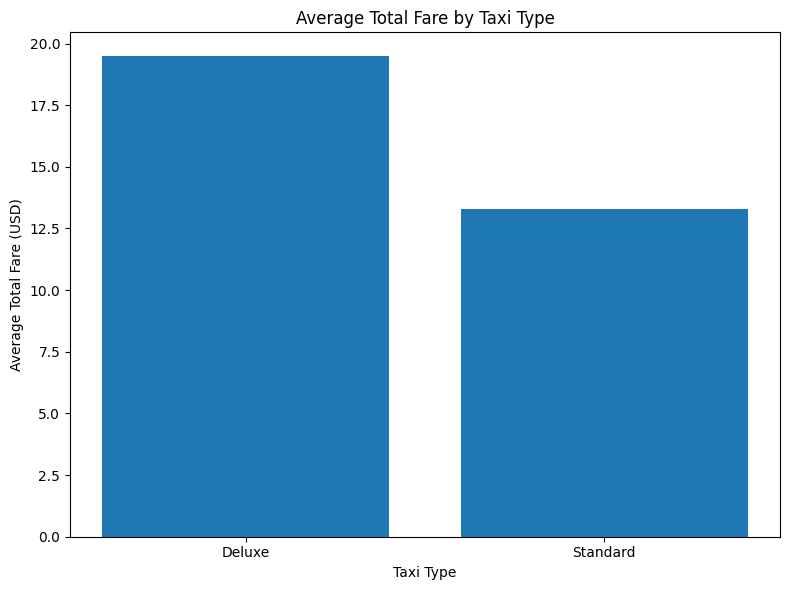

In [18]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

# Chart 1: Distribution of total fare (histogram)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['total_fare'], bins=20, edgecolor='black')
ax.set_title('Distribution of Total Fare')
ax.set_xlabel('Total Fare (USD)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Chart 2: Average total fare by taxi type (bar chart)
type_avg_fare = df.groupby('taxi_type')['total_fare'].mean()

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(type_avg_fare.index, type_avg_fare.values)
ax.set_title('Average Total Fare by Taxi Type')
ax.set_xlabel('Taxi Type')
ax.set_ylabel('Average Total Fare (USD)')
plt.tight_layout()
plt.show()


---
# 💼 Business Insights
**What did I discover?**

- **25%** of trips (70 of 280) are late-night, so the 20% surcharge applies to one trip in four.
  (심야 트립이 25%(280건 중 70건)라 4건 중 1건에 20% 할증이 적용)
- A typical fare is about **$14 to $15** (mean $14.15, median $14.61). Most trips cost between about **$5** and **$20**, with a thin tail up to about **$35**.
  (일반적인 요금은 약 $14~$15(평균 $14.15, 중앙값 $14.61). 대부분 약 $5~$20이고 약 $35까지 얇은 꼬리)
- Deluxe averages about **$19.5** and Standard about **$13.3**, a gap of about **$6**.
  (Deluxe 평균 약 $19.5, Standard 약 $13.3으로 약 $6 차이)
  

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Treat late-night as a meaningful part of revenue, because it covers **25%** of trips and carries a 20% surcharge.
   (심야는 트립의 25%에 20% 할증이 붙으므로 매출에서 의미 있는 부분으로 보기)
2. Use **$14 to $15** as the reference for a typical fare when planning prices or pricing promotions.
   (가격이나 프로모션을 정할 때 일반적인 요금의 기준은 $14~$15)
3. Check how often Deluxe is used before changing its fare, since it earns about **$6** more per trip than Standard.
   (Deluxe 요금을 바꾸기 전에 이용 빈도를 확인. Standard보다 트립당 약 $6 더 벌기 때문)
   

---
# ❌ Mistakes
**What mistakes did I make today?**

- I did not know how to choose `bins` for the histogram. For 280 trips, about 15 to 20 is a normal starting point, and I should try a few values.
  (히스토그램 bins를 어떻게 정할지 몰랐음. 280건이면 15~20 정도가 보통의 시작점이고 여러 값을 해 봐야 함)
- I first thought "Deluxe is higher" was obvious and had nothing to write. The interpretation should state how much higher and why.
  ("Deluxe가 높다"는 당연해서 쓸 게 없다고 생각했음. 얼마나 더 높고 왜 높은지를 써야 함)
  

---
# ✅ What I Learned
**Today's biggest lesson**

- `np.where(condition, value_if_true, value_if_false)` applies a conditional multiplier to a whole array without a loop.
  (np.where는 반복문 없이 배열 전체에 조건부 배율을 적용)
- A boolean column can be counted with a mask (`df[df['is_late_night']].shape[0]`), and its share is that count divided by the total.
  (불리언 컬럼은 마스크로 개수를 세고 전체로 나눠 비율을 구함)
- A histogram is read by its shape: peaks, direction of the tail, and spread. Comparing the mean and the median helps check that shape.
  (히스토그램은 모양(봉우리, 꼬리 방향, 퍼짐)으로 읽는다. 평균과 중앙값 비교가 그 모양을 확인하는 데 도움)
  

---
# 🧠 Reflection

**What was difficult?**
Reading the histogram and choosing `bins`.
(히스토그램을 읽는 것과 bins 정하기)

**Why?**
There is no single right number of bins, and I was not sure what to look for in the shape.
(bins에 정답이 없고, 모양에서 무엇을 봐야 하는지 확실하지 않았음)

**How did I solve it?**
Used `bins=20` for 280 trips, then looked at the peaks, the tail, and the spread.
(280건에 bins=20을 쓰고 봉우리, 꼬리, 퍼짐을 봤음)

**What would I do differently next time?**
Try two or three bin values (for example 10, 20, 30) and check that the shape stays about the same.
(bins를 2~3개(예: 10, 20, 30) 해 보고 모양이 비슷한지 확인)



---
# ⭐ Self Evaluation

**Understanding**
★★★★★★★☆☆☆
(배열 연산과 np.where는 이해. 히스토그램 해석은 더 연습)

**Confidence**
★★★★★★★☆☆☆

**Difficulty**
★★★★☆☆☆☆☆☆
(히스토그램 해석이 제일 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 17 — Data cleaning (Round 2/5)
  (데이터 클리닝 복습)
  